In [35]:
import pandas as pd
import seaborn as sns

from math import floor
from copy import deepcopy

import random

In [36]:
sns.set(rc={'figure.figsize': (11.7, 8.27)})

In [3]:
# Установка библиотеки sklearn
!pip3 install sklearn

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-pypi-packag

In [37]:
from sklearn.linear_model import LinearRegression

In [38]:
class ShuffleOnceRandom():
    """
    Генератор случайных чисел, который запрещает использовать
    функцию shuffle больше одного раза.
    """
    
    def __init__(self, seed=None):
        import random
        
        self._random_gen = random.Random(seed)
        self._shuffle_cnt = 0
        
    def shuffle(self, l):
        if self._shuffle_cnt > 0:
            raise RuntimeError('Нельзя использовать функцию shuffle больше одного раза')
            
        self._shuffle_cnt += 1
        self._random_gen.shuffle(l)

In [39]:
class ChoicesNRandom():
    """
    Генератор случайных чисел, который запрещает использовать
    функцию choices больше n раз.
    """
    
    def __init__(self, seed=None, n=1):
        import random
        
        self._random_gen = random.Random(seed)
        self._choices_cnt = 0
        self._n = n
        
    def choices(self, *args, **kwargs):
        if self._choices_cnt >= self._n:
            raise RuntimeError(f'Нельзя использовать функцию choices больше {self._n} раз')
            
        self._choices_cnt += 1
        return self._random_gen.choices(*args, **kwargs)

# Разбиение на обучающую, валидационную и тестовую выборки

In [40]:
def train_test_split_solution(data, 
                              train_frac,
                              random_gen):
    """
    Разбивает переданный список объектов на обучающую и тестовую выборки.
    
    Аргументы:
        data: Список объектов, который нужно разделить на части.
        train_frac: Доля объектов, которые нужно отправить в обучающую выборку.
        random_gen: Генератор случайных чисел.
        
    Возвращаемое значение:
        Пара списков: обучающая выборка, тестовая выборка.
    """
    data_new = deepcopy(data)
    random_gen.shuffle(data_new)
    training = [data_new[i] for i in range(floor(len(data_new) * train_frac))]
    test = [data_new[i] for i in range(floor(len(data_new) * train_frac), len(data_new))]
    return training, test

In [41]:
def train_test_split_tests():
    example_1_data = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    example_1_train_frac = 0.7
    example_1_random_gen = ShuffleOnceRandom(0)
    
    example_1_res = [8, 9, 2, 6, 4, 5, 3], [1, 10, 7]
    
    assert train_test_split_solution(example_1_data, 
                                     example_1_train_frac, 
                                     example_1_random_gen) == example_1_res
    
    
    example_2_data = [i % 5 for i in range(100)]
    example_2_train_frac = 0.9
    example_2_random_gen = ShuffleOnceRandom(0)
    
    example_2_res = [3, 3, 1, 2, 3, 3, 1, 1, 4, 4, 1, 3, 2, 1, 0, 2, 2, 2, 3, 1, 4, 1, 4, 0, 4, 0, 2, 4, 3, 2, 3, 1, 3, 4, 1, 3, 4, 3, 4, 4, 4, 0, 4, 0, 0, 1, 1, 1, 2, 2, 3, 0, 4, 0, 3, 1, 1, 0, 2, 0, 3, 2, 3, 0, 1, 0, 1, 0, 0, 4, 0, 1, 0, 2, 4, 2, 4, 3, 2, 3, 2, 4, 2, 0, 1, 2, 4, 2, 4, 0], [1, 3, 1, 2, 0, 3, 0, 3, 2, 4]
    
    assert train_test_split_solution(example_2_data, 
                                     example_2_train_frac, 
                                     example_2_random_gen) == example_2_res
    
    print('Все тесты прошли успешно!')

In [42]:
train_test_split_tests()

Все тесты прошли успешно!


# Кросс-валидация

In [43]:
def round_to_3(x):
    """
    Принимает число и возвращает результат его округления
    до 3 знаков после запятой.
    
    Аргументы:
        x: Число.
        
    Возвращаемое значение:
        Результат округления числа до 3 знаков после запятой.
    """
    
    return round(x, 3)

In [44]:
def split_into_k(l, k):
    """
    Разделяет список на k частей.
    
    Аргументы:
        l: Список с объектами.
        k: Число частей, на которые нужно разделить список.
        
    Возвращаемое значение:
        Возвращает список из k частей исходного списка.
    """
    
    l_mod_k = len(l) % k
    l_div_k = len(l) // k
    
    res = []
    
    for i in range(k):
        res.append(l[i * l_div_k:(i + 1) * l_div_k])
        
    for i in range(l_mod_k):
        res[i].append(l[l_div_k * k + i])
        
    return res

def score_model(model, x_test, y_test):
    """
    Оценивает точность модели по метрике «среднее отклонение от предсказанного значения».
    
    Аргументы:
        model: Модель.
        x_test: Список объектов тестовой выборки.
        y_test: Список значений предсказываемой характеристики для объектов из тестовой выборки.
                Значение на $i$-ой позиции в списке соответствует $i$-ому объекту тестовой выборки.
        
    Возвращаемое значение:
        Точность модели.
    """
    
    y_pred = model.predict(x_test)
    
    res = 0

    for i in range(len(y_test)):
        res += abs(y_pred[i] - y_test[i])
        
    return res / len(y_test)

In [45]:
def k_fold_solution(model, data_x, data_y, k, random_gen):
    """
    Проводит кросс-валидацию заданной модели методом k-Fold.
    
    Аргументы:
        model: Модель, точность которой нужно оценить с помощью кросс-валидации.
        data_x: Список объектов, на основе которых нужно построить модель.
                Каждый объект представлен списком значений факторов.
        data_y: Список значений предсказываемой величины для каждого из объектов.
                На $i$-ой позиции в списке data_y находится предсказываемое
                значение для $i$-го объекта из списка data_x.
             k: Количество частей, на которые нужно разбить данные при кросс-валидации.
        random_gen: Генератор случайных чисел.
        
    Возвращаемое значение:
        Усреднённая по всем итерациям k-Fold точность модели.
    """
    data_xy = list(zip(data_x, data_y))
    random_gen.shuffle(data_xy)
    scores = []
    split_data = split_into_k(data_xy, k)
    for i in range(k):
        test_fold = split_data[i]
        train_data = [] # extends others folds
        for  j in range(k):
            if i != j:
                train_data.extend(split_data[j])
        train_x = [item[0] for item in train_data]
        train_y = [item[1] for item in train_data]


        test_x = [item[0] for item in test_fold]
        test_y = [item[1] for item in test_fold]
        model.fit(train_x, train_y)
        score = score_model(model, test_x, test_y)
        scores.append(score)
    average_score = sum(scores) / len(scores)
    return round_to_3(average_score)

In [46]:
data_x_example_1 = [[1], [2], [3]]
data_y_example_1 = [1, 2, 3]
k_fold_solution(LinearRegression(),data_x_example_1, data_y_example_1, 3, ShuffleOnceRandom(0))

0.0

In [47]:
def k_fold_test():
    data_x_example_1 = [[1], [2], [3]]
    data_y_example_1 = [1, 2, 3]
    
    assert k_fold_solution(LinearRegression(), 
                           data_x_example_1, data_y_example_1, 3, 
                           ShuffleOnceRandom(0)) == 0.0
    
    data_example_2 = pd.read_csv('k_fold_test_data.csv')
    
    data_x_example_2 = [[x] for x in list(data_example_2['x'])]
    data_y_example_2 = list(data_example_2['y'])
    
    assert k_fold_solution(LinearRegression(), 
                           data_x_example_2, data_y_example_2, 100, 
                           ShuffleOnceRandom(0)) == 0.602
    
    print('Тест прошёл успешно!')

In [48]:
k_fold_test()

Тест прошёл успешно!


# Погрешность оценки качества

In [49]:
error_modeling_data = pd.read_csv('error_modelling.csv')

In [50]:
y = list(error_modeling_data['y'])
y_pred = list(error_modeling_data['y_pred'])

In [51]:
y_and_y_pred = list(zip(y, y_pred))

In [55]:
error_modeling_random_gen = random.Random(0)

errs = []
al_sel = sum([abs(y-y_pred) for y, y_pred in y_and_y_pred]) / len(y_and_y_pred)
for i in range(10_000):
    # необходимо сгенерировать случайную выборку объектов исходного множества
    # и оценить точность работы модели на этой выборке
    selection = error_modeling_random_gen.sample(y_and_y_pred, 100)
    err = sum([abs(y-y_pred) for y, y_pred in selection]) / len(selection)
    errs.append(err)
spec_sel = sum(errs) / len(errs)
print(al_sel)
print(spec_sel)

8.127045902234972
8.131343280284094


In [58]:
print(round(abs(al_sel-spec_sel), 3))

0.004


In [62]:
spread_rating = (sum([(err-al_sel)**2 for err in errs]) / len(errs))**(1/2)
print(round(spread_rating, 3))

1.205


<Axes: ylabel='Count'>

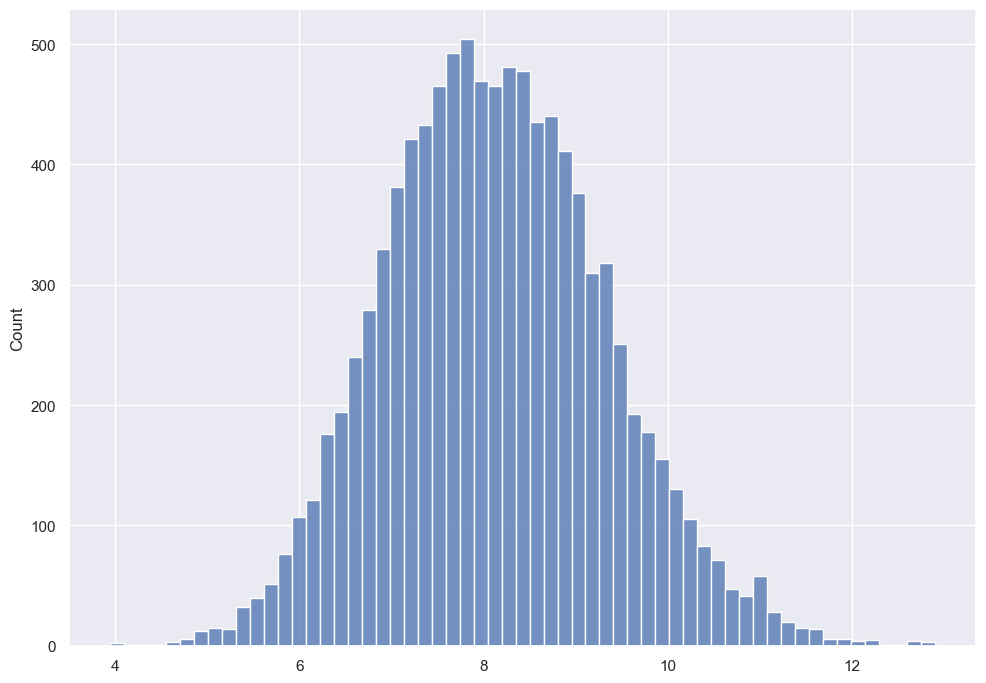

In [53]:
sns.histplot(errs)

# Бутстрап

In [63]:
def cut_on_edges(l, fraction_to_cut):
    """
    Отбрасывает с левого и с правого концов переданного списка заданную долю элементов.
    
    Аргументы:
        l: Список элементов.
        fraction_to_cut: Доля элементов, которую нужно отбросить с каждой из сторон списка.
        
    Возвращаемое значение:
        Новый список, в котором с левого и с правого концов отборешна заданная доля элементов.
    """
    
    to_cut = floor(len(l) * fraction_to_cut)
    return l[to_cut:len(l) - to_cut]

In [86]:
def bootstrap_confidence_interval_solution(y, y_pred, fraction_to_cut, random_gen):
    y_and_y_pred = list(zip(y, y_pred))
    """
    Вычисляет доверительный интервал для точности модели на тестовой выборке с помощью бутстрапа.
    
    Аргументы:
        y: Реальные значения предсказываемой характеристики для объектов тестовой выборки.
        y_pred: Предсказанные с помощью модели значения характеристики для объектов тестовой выборки.
                $i$-ый элемент списка y_pred соответствует предсказанию моделью
                значения под номером $i$ в списке y.
        fraction_to_cut: Доля элементов, которую нужно отбросить с каждого из концов списка полученных с помощью
                         бутстрапа значений перед получением доверительного интервала.
        random_gen: Генератор случайных чисел.
        
    Возвращаемое значение:
        Доверительный интервал для точности модели, оценённой по метрике
        «среднее отклонение от предсказанного значения».
        Представляется в виде пары значений: левая граница интервала, правая граница интервала.
    """
    bootstrap_ar = []
    for i in range(10000):
        gen_sel = [abs(y - y_pred) for y, y_pred in random_gen.choices(y_and_y_pred, k=len(y))]
        bootstrap_ar.append(sum(gen_sel) / len(y_and_y_pred))
    bootstrap_ar.sort()
    # print(bootstrap_ar)
    bootstrap_ar_cut = cut_on_edges(bootstrap_ar, fraction_to_cut)
    # print(bootstrap_ar_cut)
    # print(bootstrap_ar_cut[0], bootstrap_ar_cut[-1])
    return round_to_3(bootstrap_ar_cut[0]), round_to_3(bootstrap_ar_cut[-1])

In [87]:
error_modeling_data = pd.read_csv('error_modelling.csv')

y = list(error_modeling_data['y'])
y_pred = list(error_modeling_data['y_pred'])

y_y_pred = list(zip(y, y_pred))
random_gen = random.Random(0)
y_y_pred_example_1 = random_gen.sample(y_y_pred, 100)
y_example_1 = [x[0] for x in y_y_pred_example_1]
y_pred_example_1 = [x[1] for x in y_y_pred_example_1]
random_gen_example_1 = ChoicesNRandom(0, n=10000)
bootstrap_confidence_interval_solution(y_example_1, y_pred_example_1, 0.025, random_gen_example_1)

(7.178, 13.509)

In [88]:
def bootstrap_confidence_interval_test():
    error_modeling_data = pd.read_csv('error_modelling.csv')
    
    y = list(error_modeling_data['y'])
    y_pred = list(error_modeling_data['y_pred'])
    
    y_y_pred = list(zip(y, y_pred))
    
    random_gen = random.Random(0)
    y_y_pred_example_1 = random_gen.sample(y_y_pred, 100)
    
    y_example_1 = [x[0] for x in y_y_pred_example_1]
    y_pred_example_1 = [x[1] for x in y_y_pred_example_1]
    random_gen_example_1 = ChoicesNRandom(0, n=10000)
    
    res_example_1 = 7.178, 13.509
    
    assert bootstrap_confidence_interval_solution(y_example_1, y_pred_example_1, 0.025, random_gen_example_1) == res_example_1
    
    print('Тест прошёл успешно!')

In [89]:
bootstrap_confidence_interval_test()

Тест прошёл успешно!
